In [1]:
import os
import glob
import yaml

import torch
torch.set_default_dtype(torch.double)
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision  
import matplotlib.pyplot as plt

from archetypes import AA
from nflows.distributions import StandardNormal
from nflows.flows import Flow
from nflows.transforms.normalization import ActNorm
from nflows.transforms import OneByOneConvolution, SqueezeTransform
from tqdm import tqdm

# concave
from src.concaves.log import LogConcave

# diffeomorphisms
from src.diffeomorphisms.composition.image import ImageCompositionDiffeomorphism
from src.diffeomorphisms.image.concave import ConcaveImageDiffeomorphism
from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.diffeomorphisms.image.star import StarImageDiffeomorphism

# disributions
from src.distributions.stars.ellipsoid.multimodal.data_enclosing import MultimodalDataEnclosingEllipsoidStarDistribution

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# nflow training
from src.nflow_training import NFlowTraining

# RAM
from src.nn.module.riemannian.archetypal_mapping import RiemannianArchetypalMapping

# transforms
from src.transforms.composite.image import ImageCompositeTransform
from src.transforms.image import ImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set random seed
torch.manual_seed(31)

# declare exp digit
exp_digit = 2

# ---- load YAML config ----
config_path = os.path.join("configs", "single_digit_mnist.yaml")
with open(config_path, "r") as f:
        config = yaml.safe_load(f)

data_cfg = config["data"]
nflow_cfg = config["nflow"]
starflow_cfg = config["starflow"]

size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

nflow_training = nflow_cfg["enabled"]
starflow_training = starflow_cfg["enabled"]

base_results_folder = os.path.join("results", "single_digit_mnist", f"digit_{exp_digit}")
os.makedirs(base_results_folder, exist_ok=True)

results_folder = os.path.join(
    base_results_folder,
    f"{size}x{size}",
)
os.makedirs(results_folder, exist_ok=True)


Using NumPy backend


In [2]:
H = W = size
mnist_mean = data_cfg["mnist_mean"]
mnist_var = data_cfg["mnist_var"]
train_val_split = data_cfg["train_val_split"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Collect all images with label == exp_digit
data = []

for x, y in full_dataset:
    if y == exp_digit:
        data.append(x)          # x has shape 1 x H x W

# Stack into tensors
data = torch.stack(data, dim=0)        # shape: N x 1 x H x W

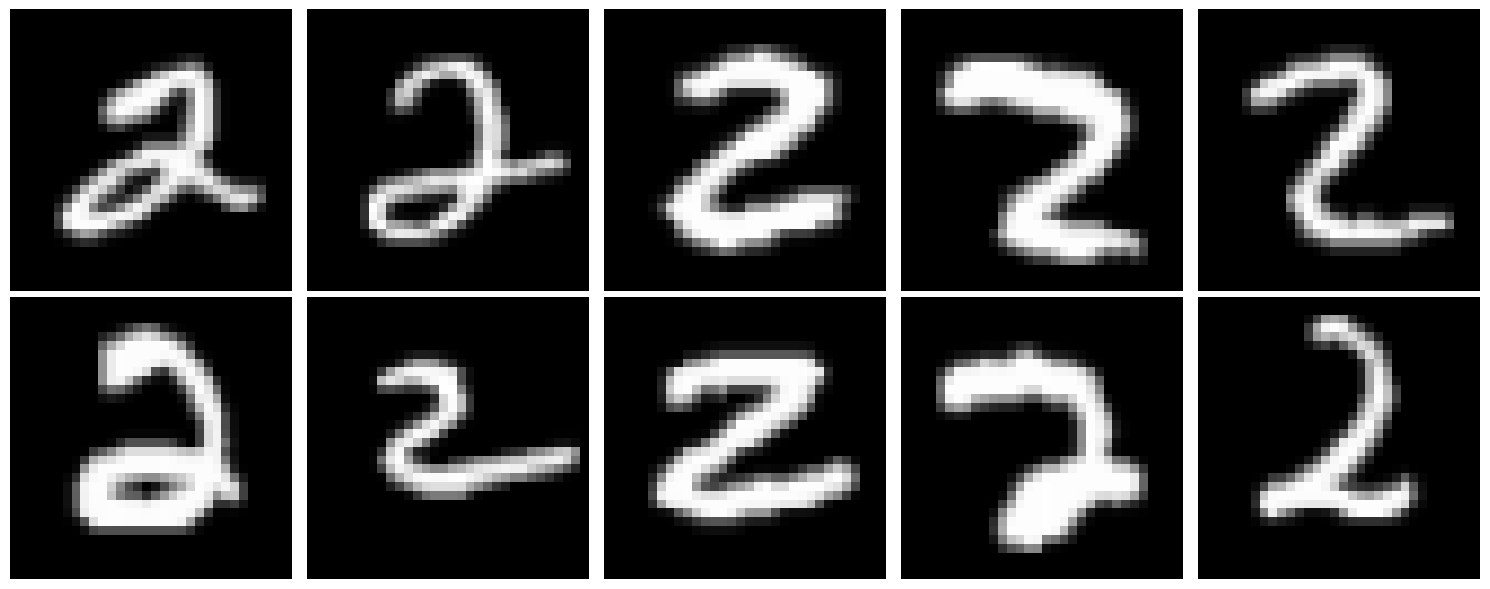

In [3]:
# plot some images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(data[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# construct train and val datasets
data_size = data.shape[0]
train_size = int(train_val_split * data_size)
val_size = data_size - train_size
data_train, data_val = data[:train_size], data[train_size:]

print("Data shapes: \n data.shape = {} \n data_train.shape = {} \n data_val.shape = {}".format(data.shape, data_train.shape, data_val.shape))

Data shapes: 
 data.shape = torch.Size([5958, 1, 32, 32]) 
 data_train.shape = torch.Size([4766, 1, 32, 32]) 
 data_val.shape = torch.Size([1192, 1, 32, 32])


In [5]:
# create dataset and dataloader
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)

## Learn an NFlow ##

In [6]:
class MultiLevelImageTransform(ImageTransform):
    def __init__(self, in_channels, height, width, image_transforms):
        """
        :param image_transforms: list of ImageTransform objects, one for each level of the multi-level transform.
        """
        self.L = len(image_transforms)
        assert image_transforms[0].C == in_channels * 4
        assert image_transforms[0].H == height // 2
        assert image_transforms[0].W == width // 2
        # assert that the image transform dimensions shrink by a factor of 2 at each level, but channels grow by a factor of 2 at each level
        assert all(image_transforms[i].C == image_transforms[i-1].C * 2 for i in range(1, self.L))
        assert all(image_transforms[i].H == image_transforms[i-1].H // 2 for i in range(1, self.L))
        assert all(image_transforms[i].W == image_transforms[i-1].W // 2 for i in range(1, self.L))
        super().__init__(in_channels, height, width)
        self.image_transforms = nn.ModuleList(image_transforms)

        self.squeeze = SqueezeTransform(factor=2)
        

    def forward(self, inputs, context=None):
        batch_size = inputs.shape[0]
        outputs = inputs
        total_logabsdet = inputs.new_zeros(batch_size)
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, log_abs_det = self.squeeze(outputs, None)
            total_logabsdet += log_abs_det

            # flow step
            outputs, log_abs_det = self.image_transforms[i](outputs, None)
            total_logabsdet += log_abs_det

            # split
            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # add context if provided
        if context is not None:
            assert context.shape[0] == batch_size
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs - context_

        # iterate through splits to get outputs in correct order
        for i in reversed(range(self.L)):
            # concatenate split back to outputs
            outputs = torch.cat([splits[i], outputs], dim=1)
            # unsqueeze
            outputs, _ = self.squeeze.inverse(outputs, None)

        return outputs, total_logabsdet
    
    def inverse(self, inputs, context=None):
        # iterate through splits to get outputs in correct order
        outputs = inputs
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, _ = self.squeeze(outputs, None)

            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # remove context if provided
        if context is not None:
            assert context.shape[0] == inputs.shape[0]
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs + context_

        total_logabsdet = inputs.new_zeros(inputs.shape[0])
        for i in reversed(range(self.L)):
            # concatenate
            outputs = torch.cat([splits[i], outputs], dim=1)

            # flow step
            outputs, log_abs_det = self.image_transforms[i].inverse(outputs, None)
            total_logabsdet += log_abs_det

            # unsqueeze
            outputs, log_abs_det = self.squeeze.inverse(outputs, None)
            total_logabsdet += log_abs_det

        return outputs, total_logabsdet

In [7]:
class SimpleMultiLevelImageTransform(MultiLevelImageTransform):
    def __init__(self, in_channels, height, width, kernel_size=3, hidden_channels=64, n_flows=3, n_scales=3):
        super().__init__(in_channels, height, width, [self.create_transform(in_channels * (2 ** i) * 2, height // (2 ** i), width // (2 ** i), kernel_size, hidden_channels, n_flows) for i in range(1, n_scales+1)])

    def create_transform(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        transforms_list = []
        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels)) # OneByOneConvolution
            transforms_list.append(OneByOneConvolution(in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(OneByOneConvolution(in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transform = ImageCompositeTransform(in_channels, height, width, transforms_list)
        return transform

In [8]:
# construct nflow and trainer
nflow = Flow(transform=SimpleMultiLevelImageTransform(in_channels=1, height=H, width=W, kernel_size=nflow_cfg["kernel_size"], hidden_channels=nflow_cfg["hidden_channels"], n_flows=nflow_cfg["n_flows"], n_scales=nflow_cfg["n_scales"]),
             distribution=StandardNormal(shape=[1, H, W])).to(device)

nflow_trainer = NFlowTraining(nflow)

In [9]:
# construct train loop
def train_nflow(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf'), save_every=10):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for x in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.nflow.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        if (epoch+1) % save_every == 0 or (epoch+1) == n_epochs:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [10]:
# train or load nflow model
nflow_extension = f"lr_{nflow_cfg['learning_rate']}_kernel_{nflow_cfg['kernel_size']}_hidden_{nflow_cfg['hidden_channels']}_flows_{nflow_cfg['n_flows']}_scales_{nflow_cfg['n_scales']}"
checkpoint_dir = os.path.join(results_folder, nflow_cfg["checkpoint_subdir"], nflow_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if nflow_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])
        nflow_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    train_nflow(
        nflow_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=nflow_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])

Resuming training from results/single_digit_mnist/digit_2/32x32/checkpoints_nflow/lr_0.001_kernel_3_hidden_64_flows_3_scales_3/epoch_50_model.pth
Training completed. Best model saved with loss: -1079.6473215126064


In [11]:
# construct diffeomorphism from nflow
phi = NFlowImageDiffeomorphism(1, H, W, nflow_trainer.nflow)

# construct pullback manifold and ref manifold
phi_manifold = StandardPullbackImageEuclidean(phi)
l2_euclidean = StandardImageEuclidean(1, H, W)

In [12]:
phi_data_train = torch.zeros_like(data_train)
i = 0
with torch.no_grad():
    for x in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        b = x.size(0)                      # actual batch size
        phi_data_train[i:i+b] = phi(x).cpu()
        i += b

  0%|          | 0/38 [00:00<?, ?it/s]

100%|██████████| 38/38 [00:03<00:00,  9.85it/s]


In [13]:
# construct archetypes from mapped train data
n_archetypes = starflow_cfg["n_archetypes"]

aa = AA(n_archetypes=n_archetypes, init='furthest_sum')
aa.fit(phi_data_train.reshape(train_size, -1))
# phi_archetypes_train = torch.from_numpy(aa.archetypes_)
labels_train = torch.from_numpy(aa.labels_)

n_classes = len(torch.unique(labels_train))
print(f"Number of archetypes: {n_archetypes}, Number of classes (unique labels): {n_classes}")

# map archetypes back to image space
phi_archetypes_train = [] # list of length n_classes, each element is a tensor of shape (H*W)
phi_centers_train = []  # list of length n_classes, each element is a tensor of shape (H*W)
phi_labeled_data_train = []  # list of length n_classes, each element is a tensor of shape (num_samples_in_class, H*W)

for label in torch.unique(labels_train):
        phi_archetypes_train.append(torch.from_numpy(aa.archetypes_)[label])
        phi_centers_train.append(phi_data_train[labels_train == label].mean(dim=0).reshape(-1))
        phi_labeled_data_train.append(phi_data_train[labels_train == label].reshape(-1, H * W))

with torch.no_grad(): 
        archetypes_train = phi.inverse(torch.stack(phi_archetypes_train).to(device).reshape(n_classes, 1, H, W)).cpu()
        centers_train = phi.inverse(torch.stack(phi_centers_train).to(device).reshape(n_classes, 1, H, W)).cpu()

Number of archetypes: 10, Number of classes (unique labels): 10


/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(


In [14]:
print(archetypes_train.shape)

torch.Size([10, 1, 32, 32])


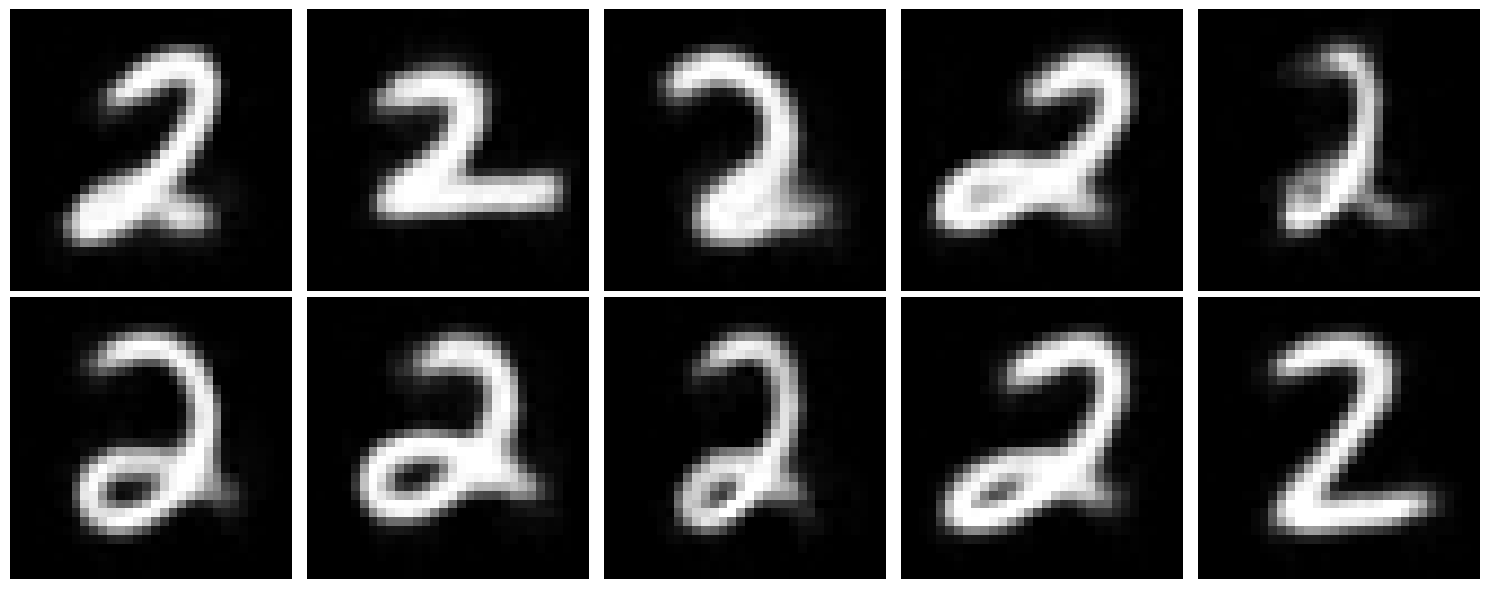

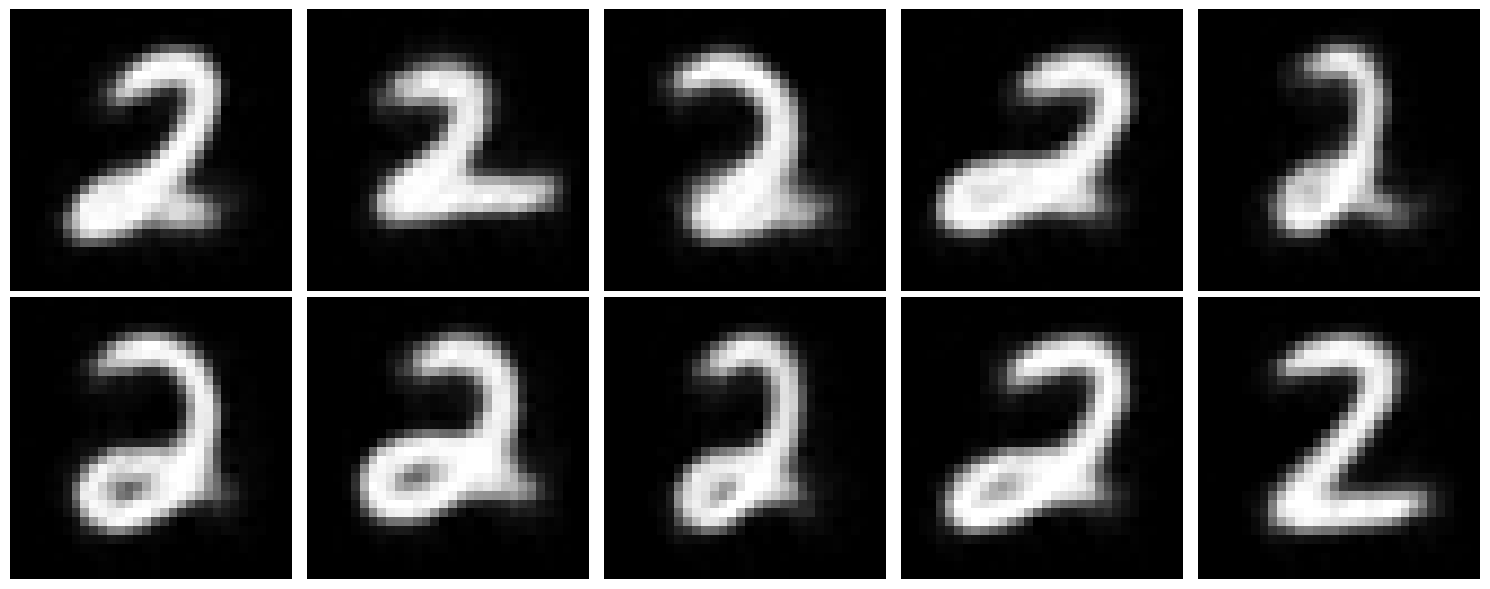

In [15]:
# visualize archetypes and centers
num_vertical = n_classes // 5

fig, axes = plt.subplots(num_vertical, 5, figsize=(15, 3 * num_vertical))
axes = axes.flatten()
for i in range(n_classes):
    if i >=  num_vertical * 5:
        break
    axes[i].imshow(archetypes_train[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off') 
plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"archetypes_phi.png"))
plt.show()

fig, axes = plt.subplots(num_vertical, 5, figsize=(15, 3 * num_vertical))
axes = axes.flatten()
for i in range(n_classes):
    if i >=  num_vertical * 5:
        break
    axes[i].imshow(centers_train[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"centers_phi.png"))
plt.show()

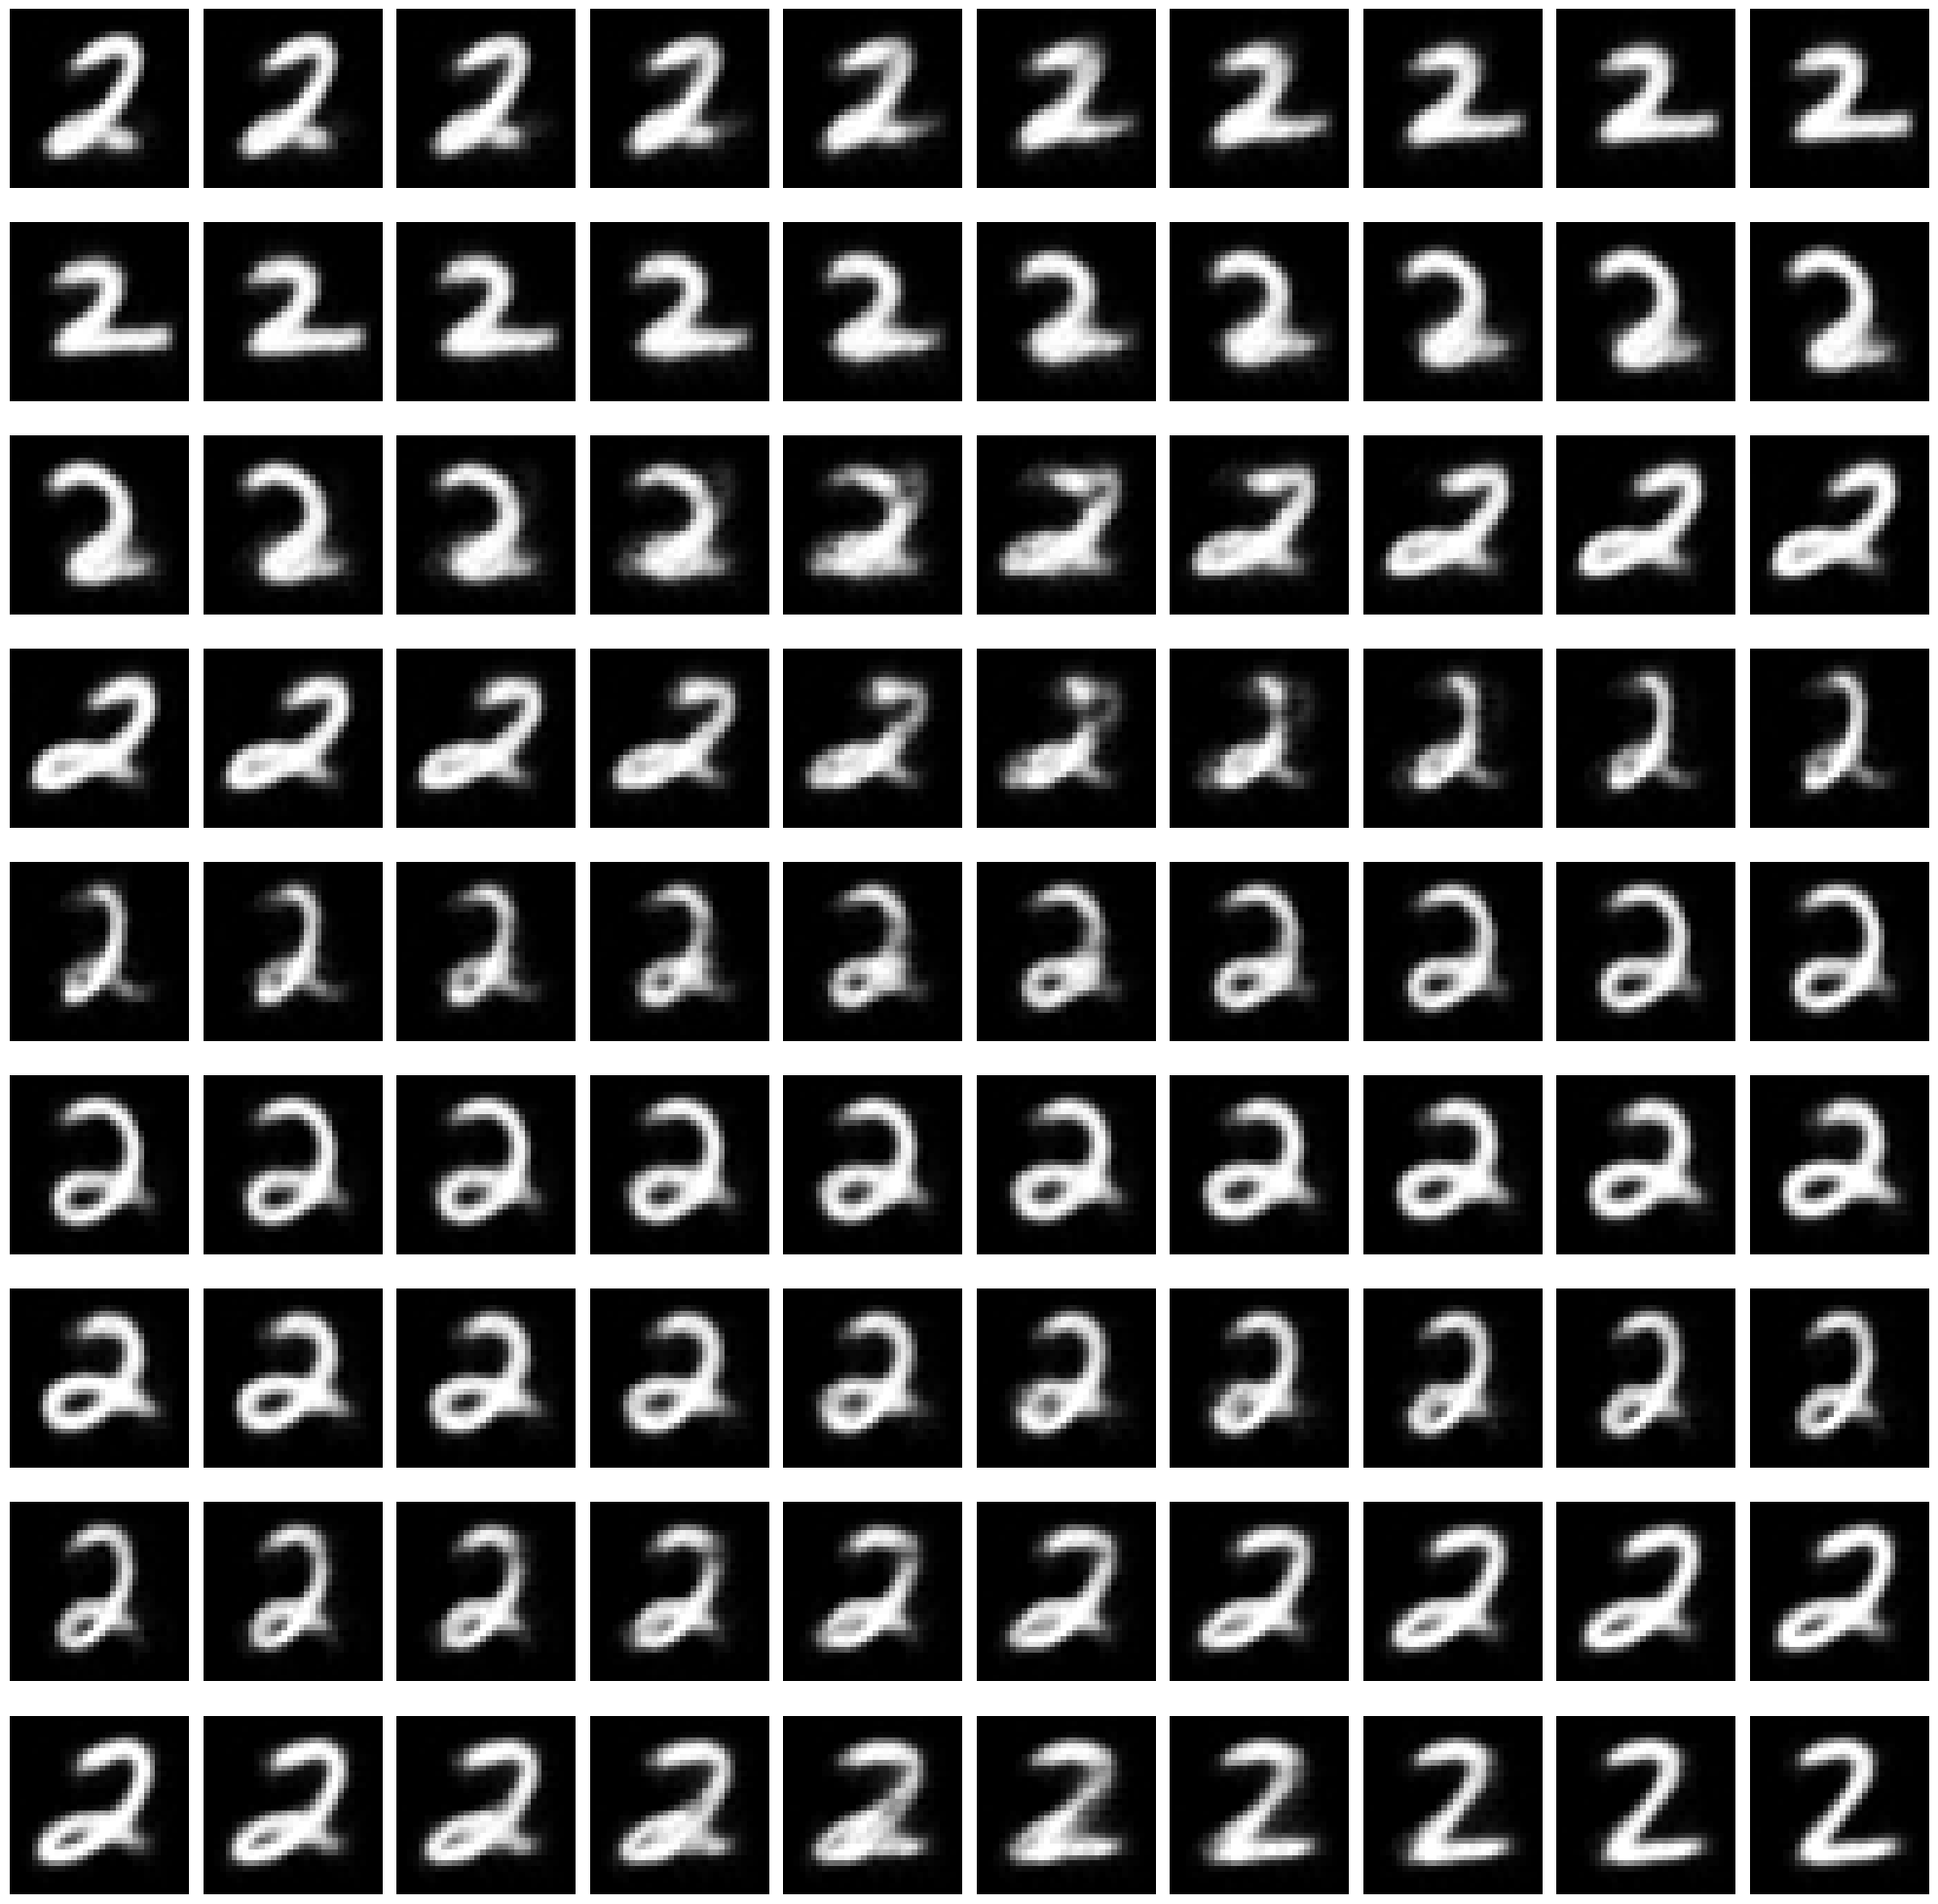

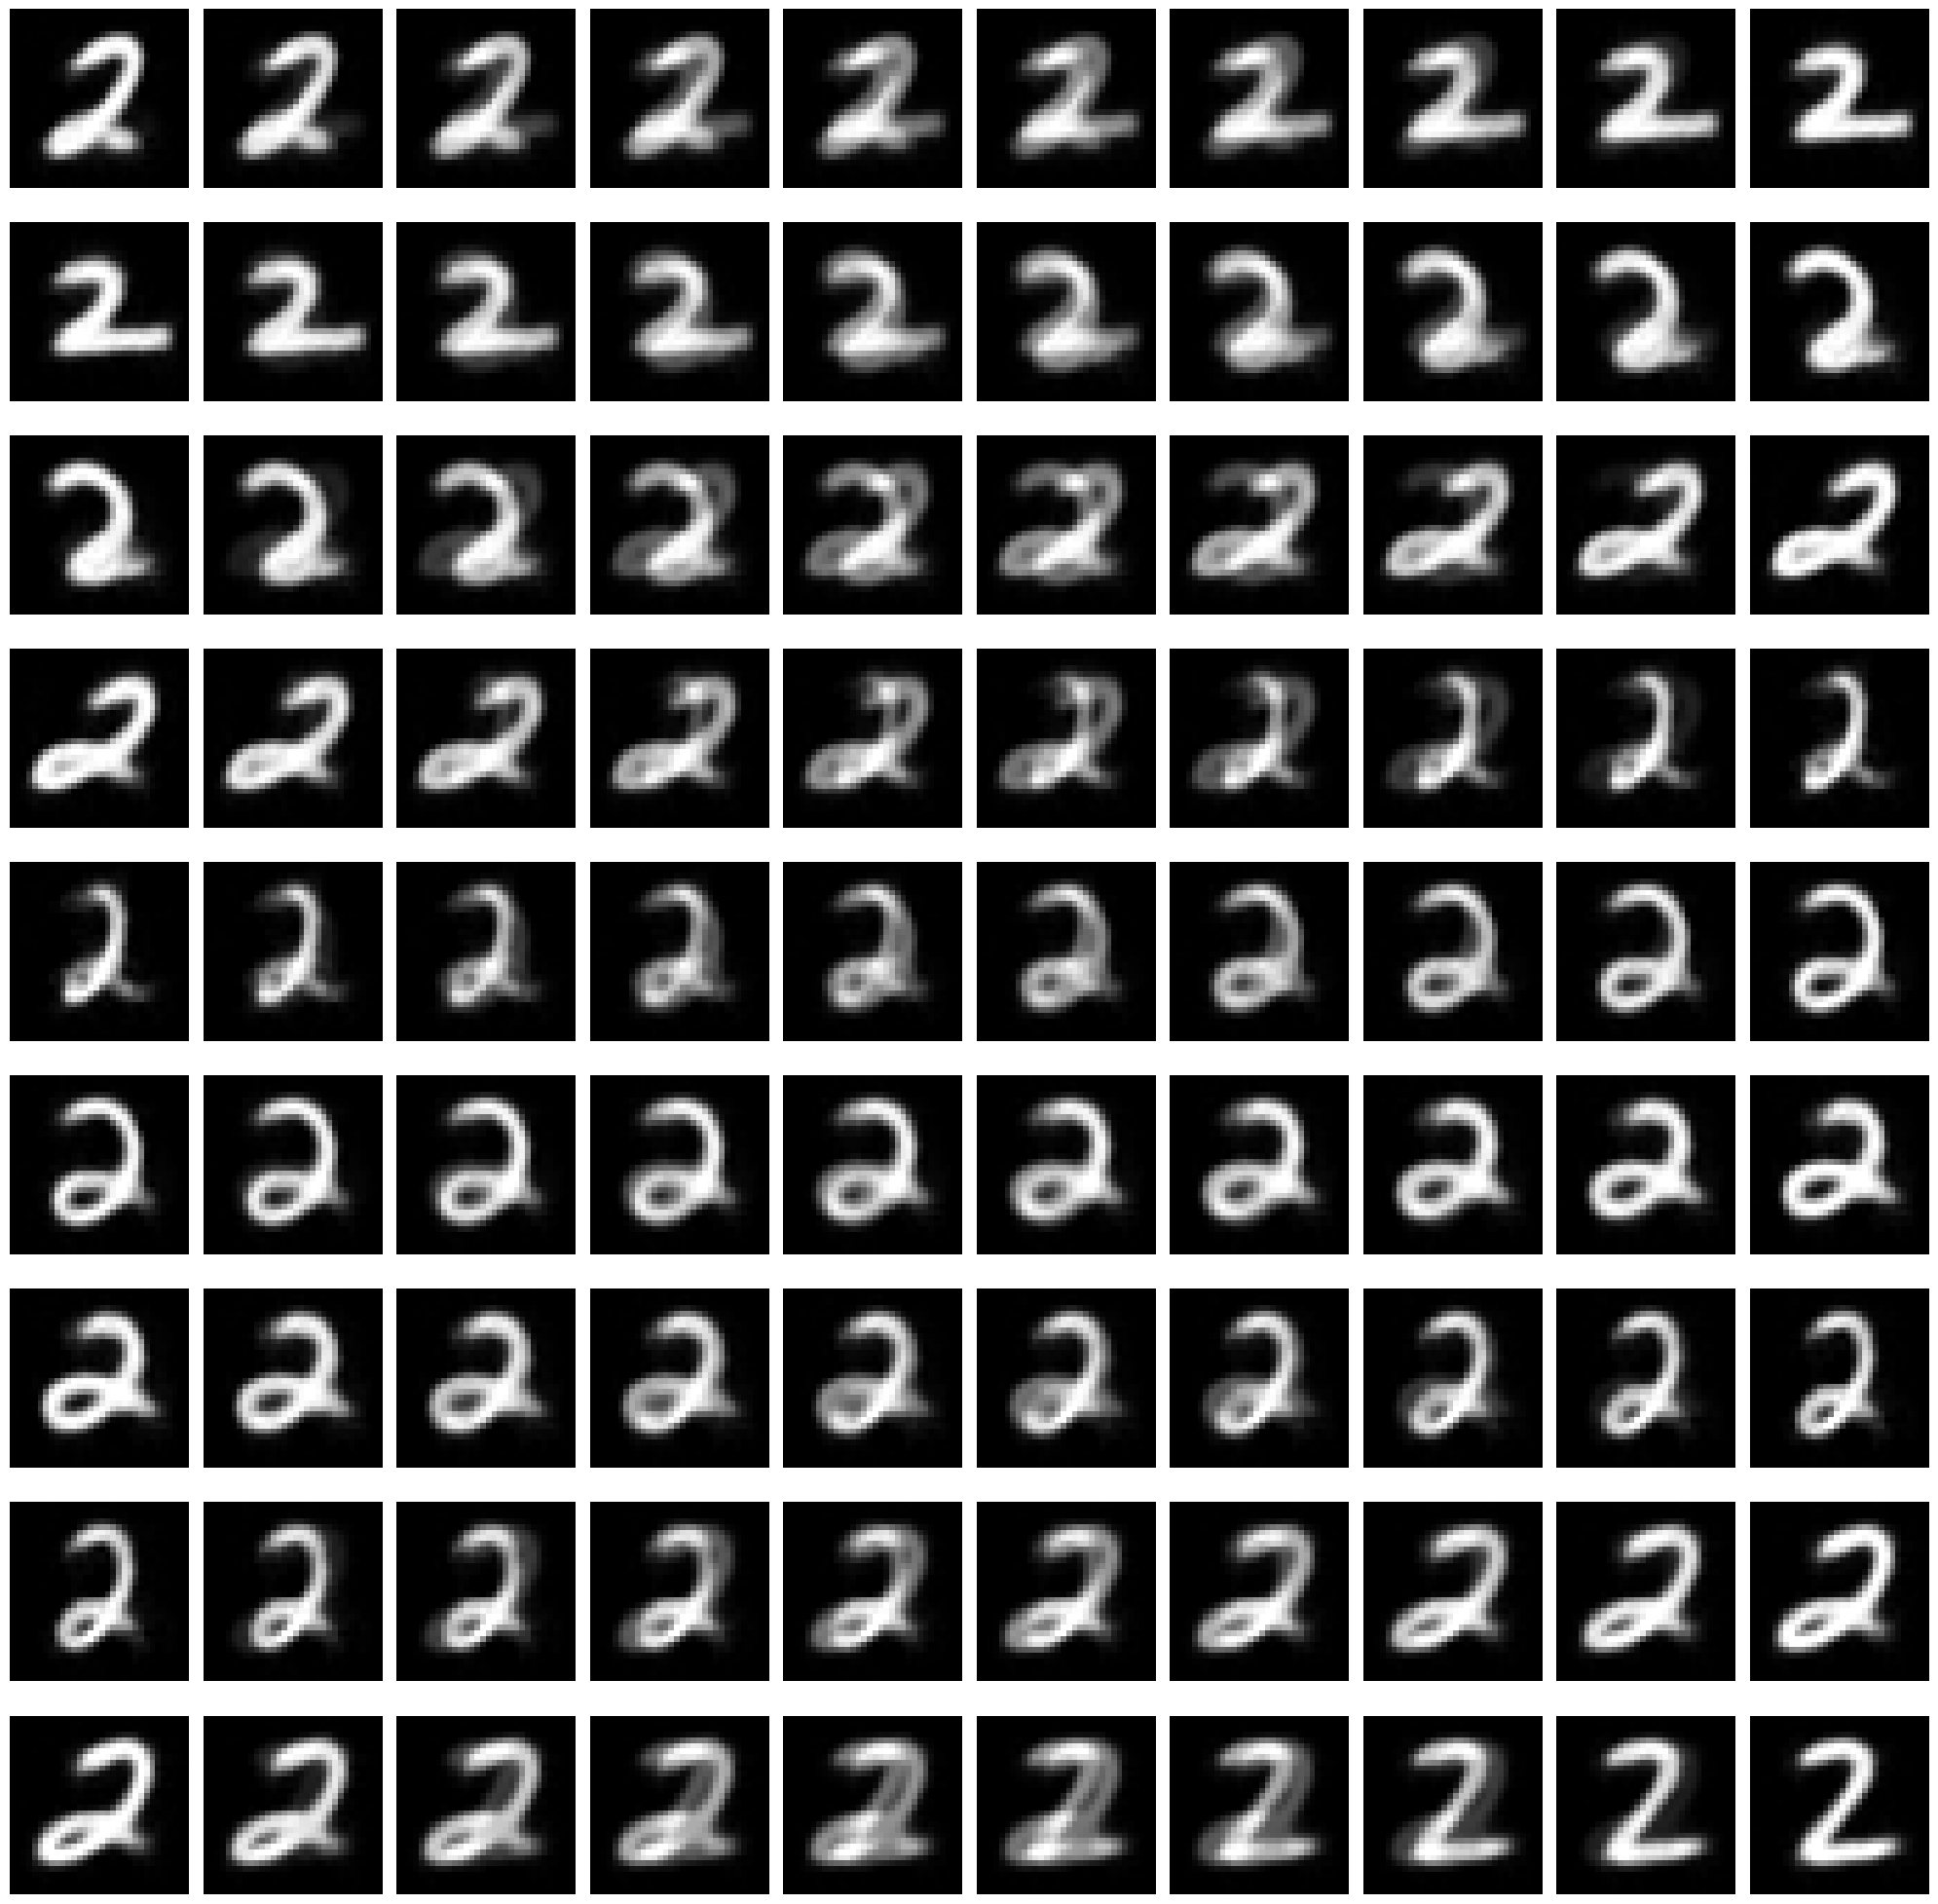

In [16]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    phi_geodesics = phi_manifold.geodesic(archetypes_train[None].to(device), archetypes_train[None].to(device), t.to(device))[0].cpu()
    interpolations = l2_euclidean.geodesic(archetypes_train[None], archetypes_train[None], t)[0]

# plot geodesics
fig, axes = plt.subplots(n_classes-1, steps, figsize=(int(steps / n_classes * 20), 20))
axes = axes.flatten()
for i in range(n_classes-1):
    for k in range(steps):
        axes[i*steps + k].imshow(phi_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_phi.png"))
plt.show()

# plot interpolations
fig, axes = plt.subplots(n_classes-1, steps, figsize=(int(steps / n_classes * 20), 20))
axes = axes.flatten()
for i in range(n_classes-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow(interpolations[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"linear_interpolations.png"))
plt.show()

## Learn a Latent Space Star ##

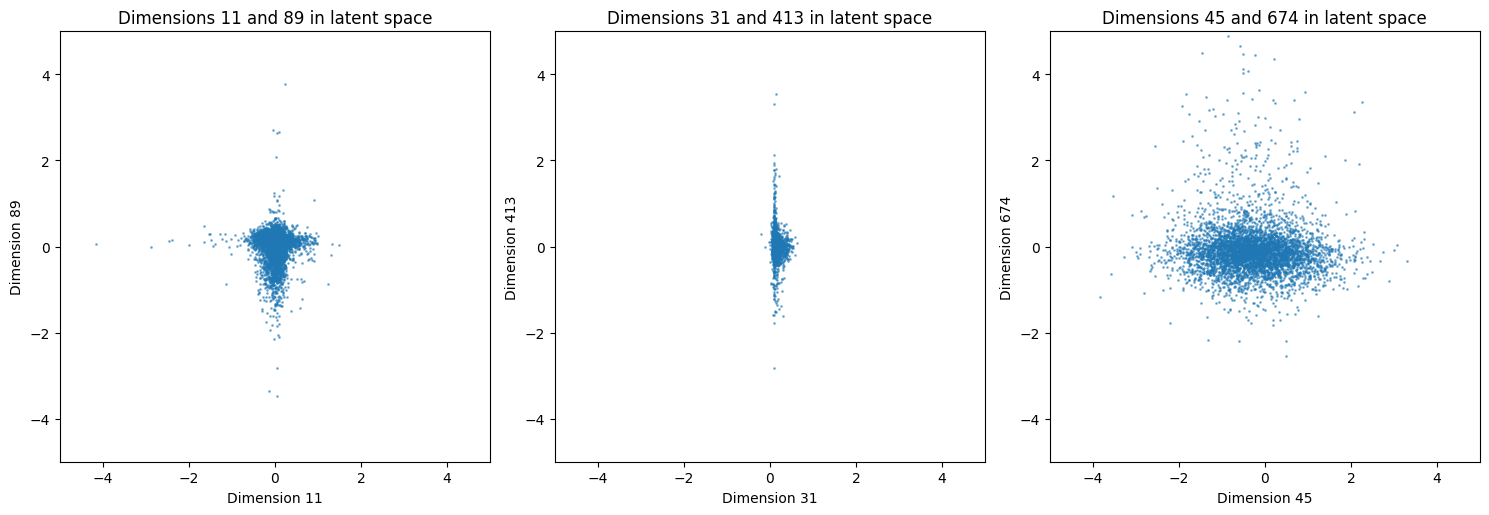

In [17]:
# plot first two dimensions of phi_data_train
dims_1 = [11, 89]
dims_2 = [31, 413]
dims_3 = [45, 674]

# three scatter plots of different dimensions of phi_data_train
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(phi_data_train.reshape(-1, size*size)[:, dims_1[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_1[1]].numpy(), s=1, alpha=0.5)
ax[0].set_title(f"Dimensions {dims_1[0]} and {dims_1[1]} in latent space")
ax[0].set_xlabel(f"Dimension {dims_1[0]}")
ax[0].set_ylabel(f"Dimension {dims_1[1]}")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-5, 5)

ax[1].scatter(phi_data_train.reshape(-1, size*size)[:, dims_2[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_2[1]].numpy(), s=1, alpha=0.5)
ax[1].set_title(f"Dimensions {dims_2[0]} and {dims_2[1]} in latent space")
ax[1].set_xlabel(f"Dimension {dims_2[0]}")
ax[1].set_ylabel(f"Dimension {dims_2[1]}")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-5, 5)

ax[2].scatter(phi_data_train.reshape(-1, size*size)[:, dims_3[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_3[1]].numpy(), s=1, alpha=0.5)
ax[2].set_title(f"Dimensions {dims_3[0]} and {dims_3[1]} in latent space")
ax[2].set_xlabel(f"Dimension {dims_3[0]}")
ax[2].set_ylabel(f"Dimension {dims_3[1]}")
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlim(-5, 5)
ax[2].set_ylim(-5, 5)
plt.tight_layout()
plt.show()

In [18]:
for i in range(n_classes):
    print(f"Label {i}: phi Center shape: {phi_centers_train[i].shape}, phi Archetypes shape: {phi_archetypes_train[i].shape}")
    print(f"Label {i}: Center shape: {centers_train[i].shape}, Archetypes shape: {archetypes_train[i].shape}")

Label 0: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 0: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([1, 32, 32])
Label 1: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 1: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([1, 32, 32])
Label 2: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 2: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([1, 32, 32])
Label 3: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 3: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([1, 32, 32])
Label 4: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 4: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([1, 32, 32])
Label 5: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([1024])
Label 5: Center shape:

In [19]:
# construct star from archetypes
star = MultimodalDataEnclosingEllipsoidStarDistribution(phi_labeled_data_train, phi_centers_train, reg_param=1e-3)

In [20]:
# construct manifold
chi = StarImageDiffeomorphism(1, H, W, star).to(device)
Omega = ImageCompositionDiffeomorphism([phi, chi], 1, H, W)
# Omega = ImageCompositionDiffeomorphism([phi, chi, ConcaveImageDiffeomorphism(1, H, W, LogConcave(a=10.))], 1, H, W)
# construct pullback manifold
Omega_manifold = StandardPullbackImageEuclidean(Omega)
iso_Omega_manifold = l2IsometrizedImageEuclidean(Omega_manifold, num_intervals=20)

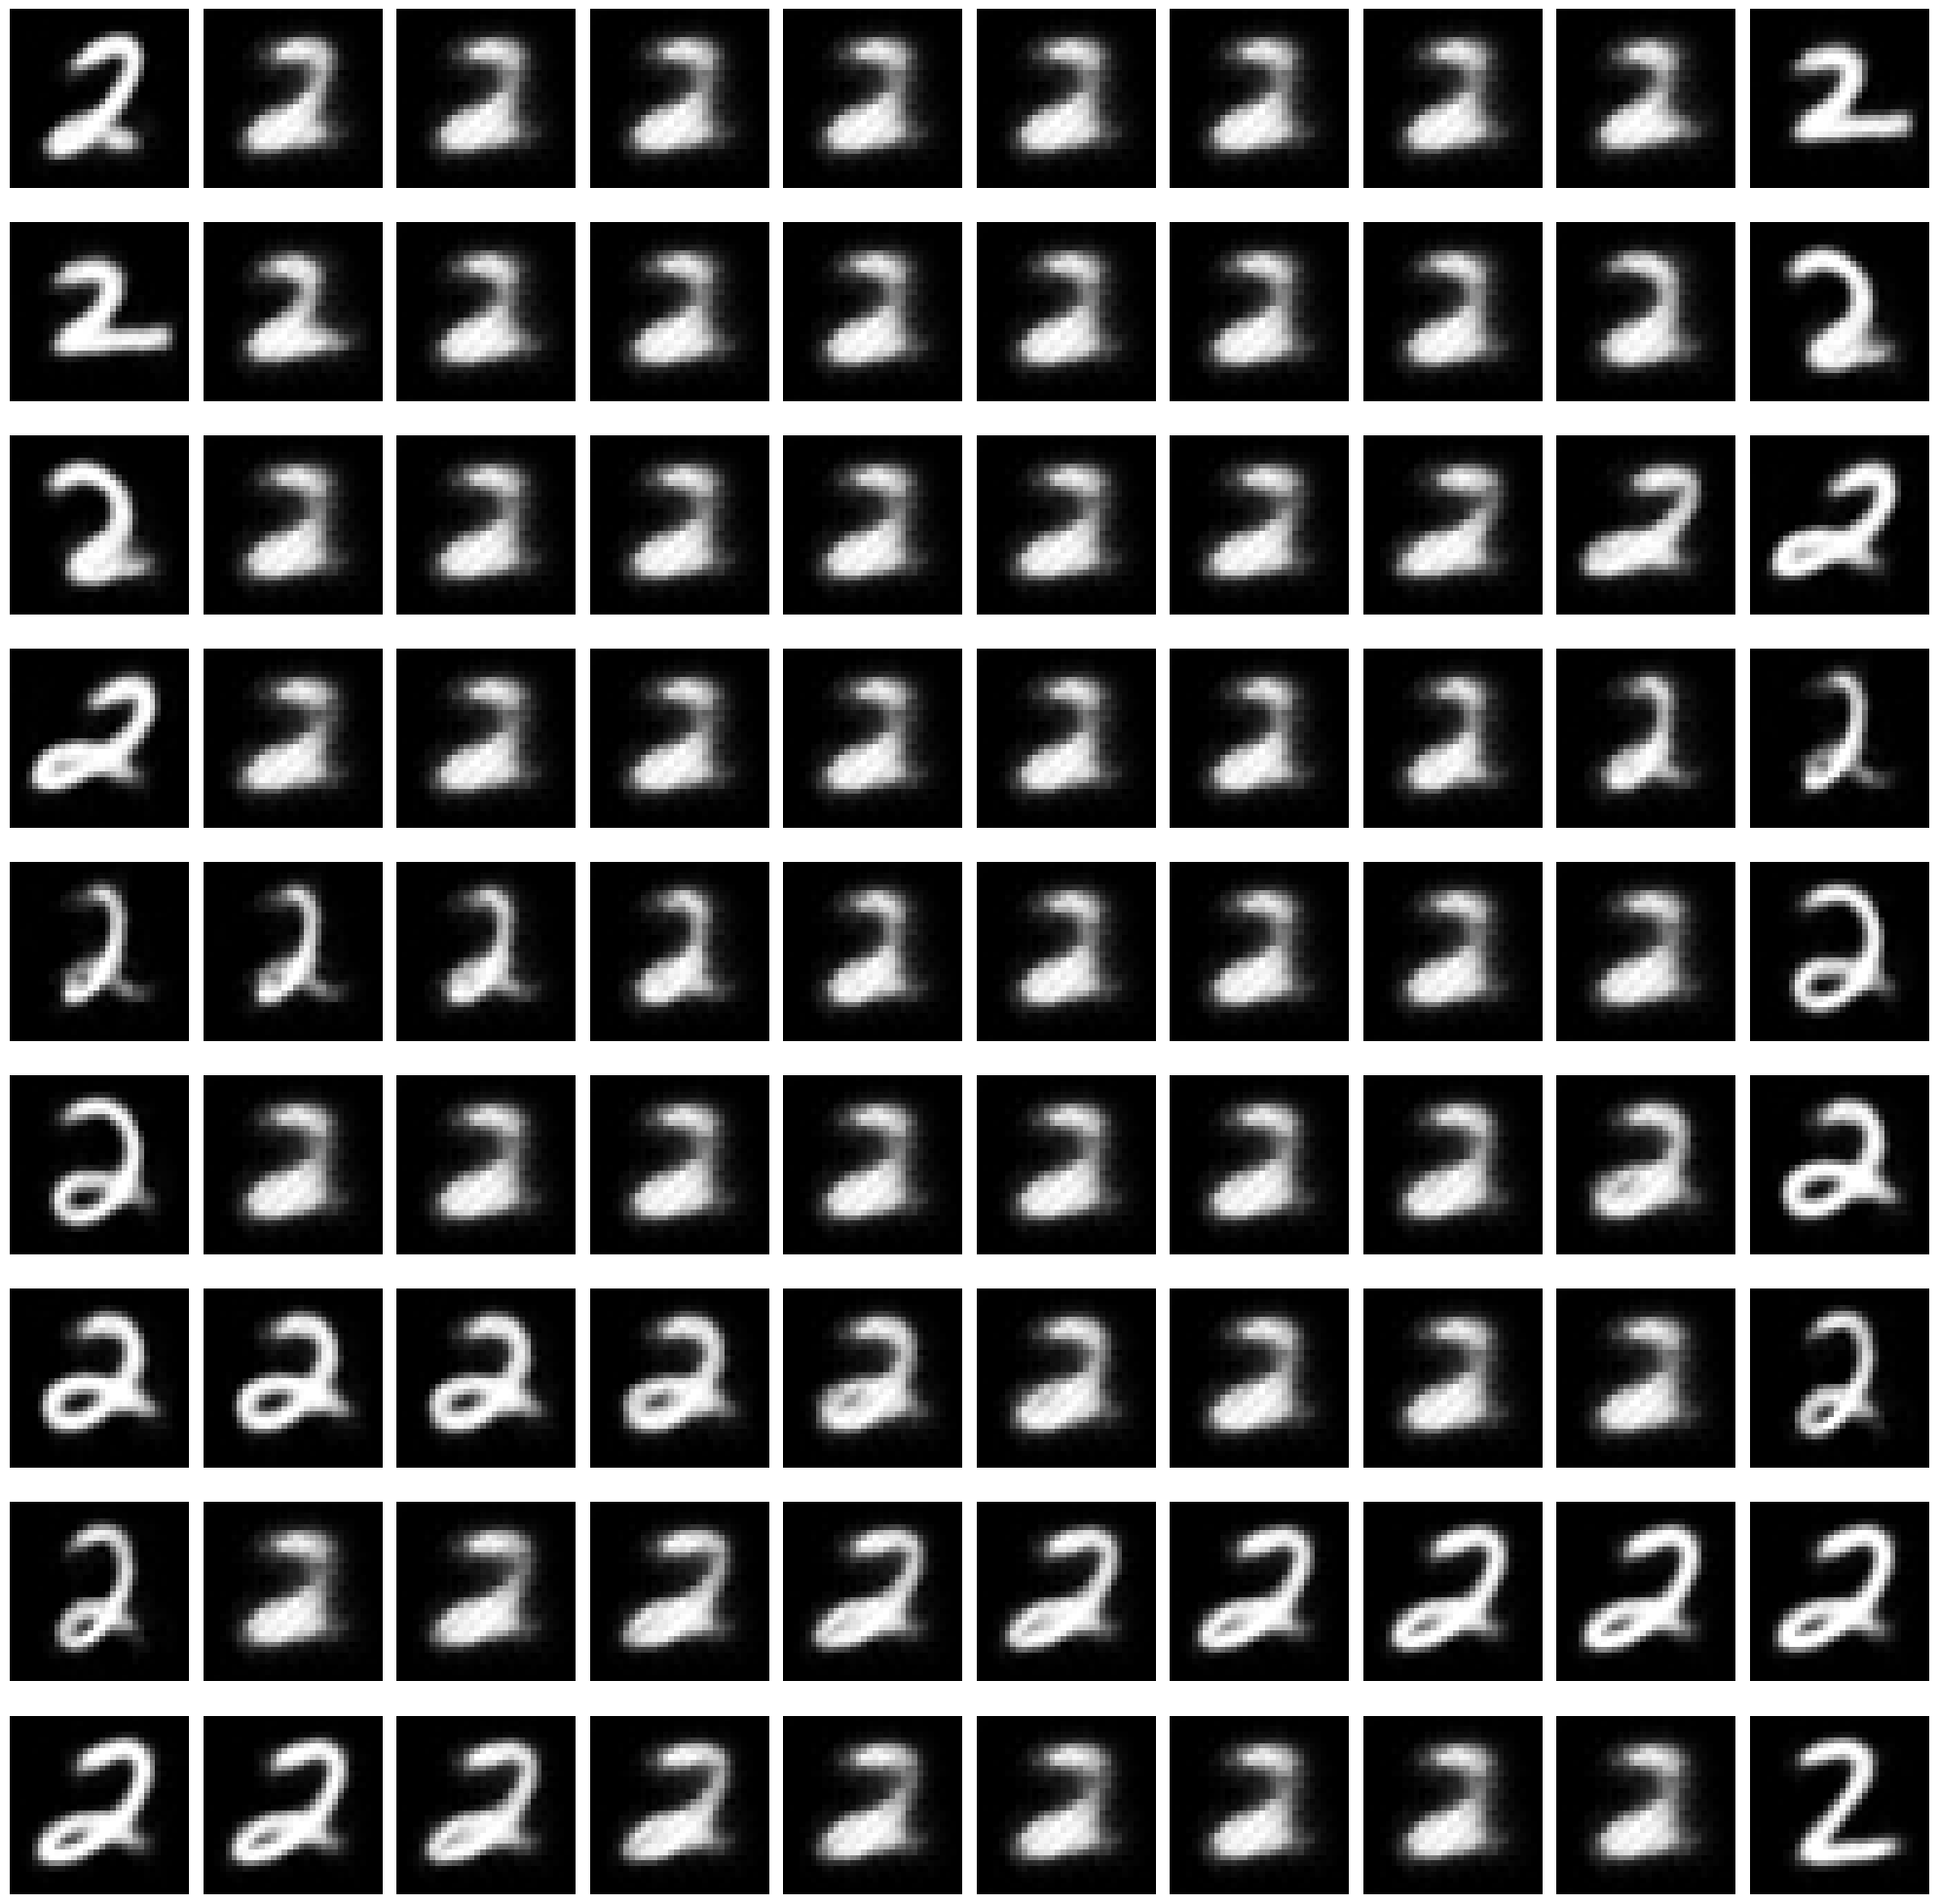

In [21]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    Omega_geodesics = Omega_manifold.geodesic(archetypes_train[None].to(device), archetypes_train[None].to(device), t.to(device))[0].cpu() 

# plot geodesics
fig, axes = plt.subplots(n_classes-1, steps, figsize=(int(steps / n_classes * 20), 20))
axes = axes.flatten()
for i in range(n_classes-1):
    for k in range(steps):
        axes[i*steps + k].imshow(Omega_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega.png"))
plt.show()

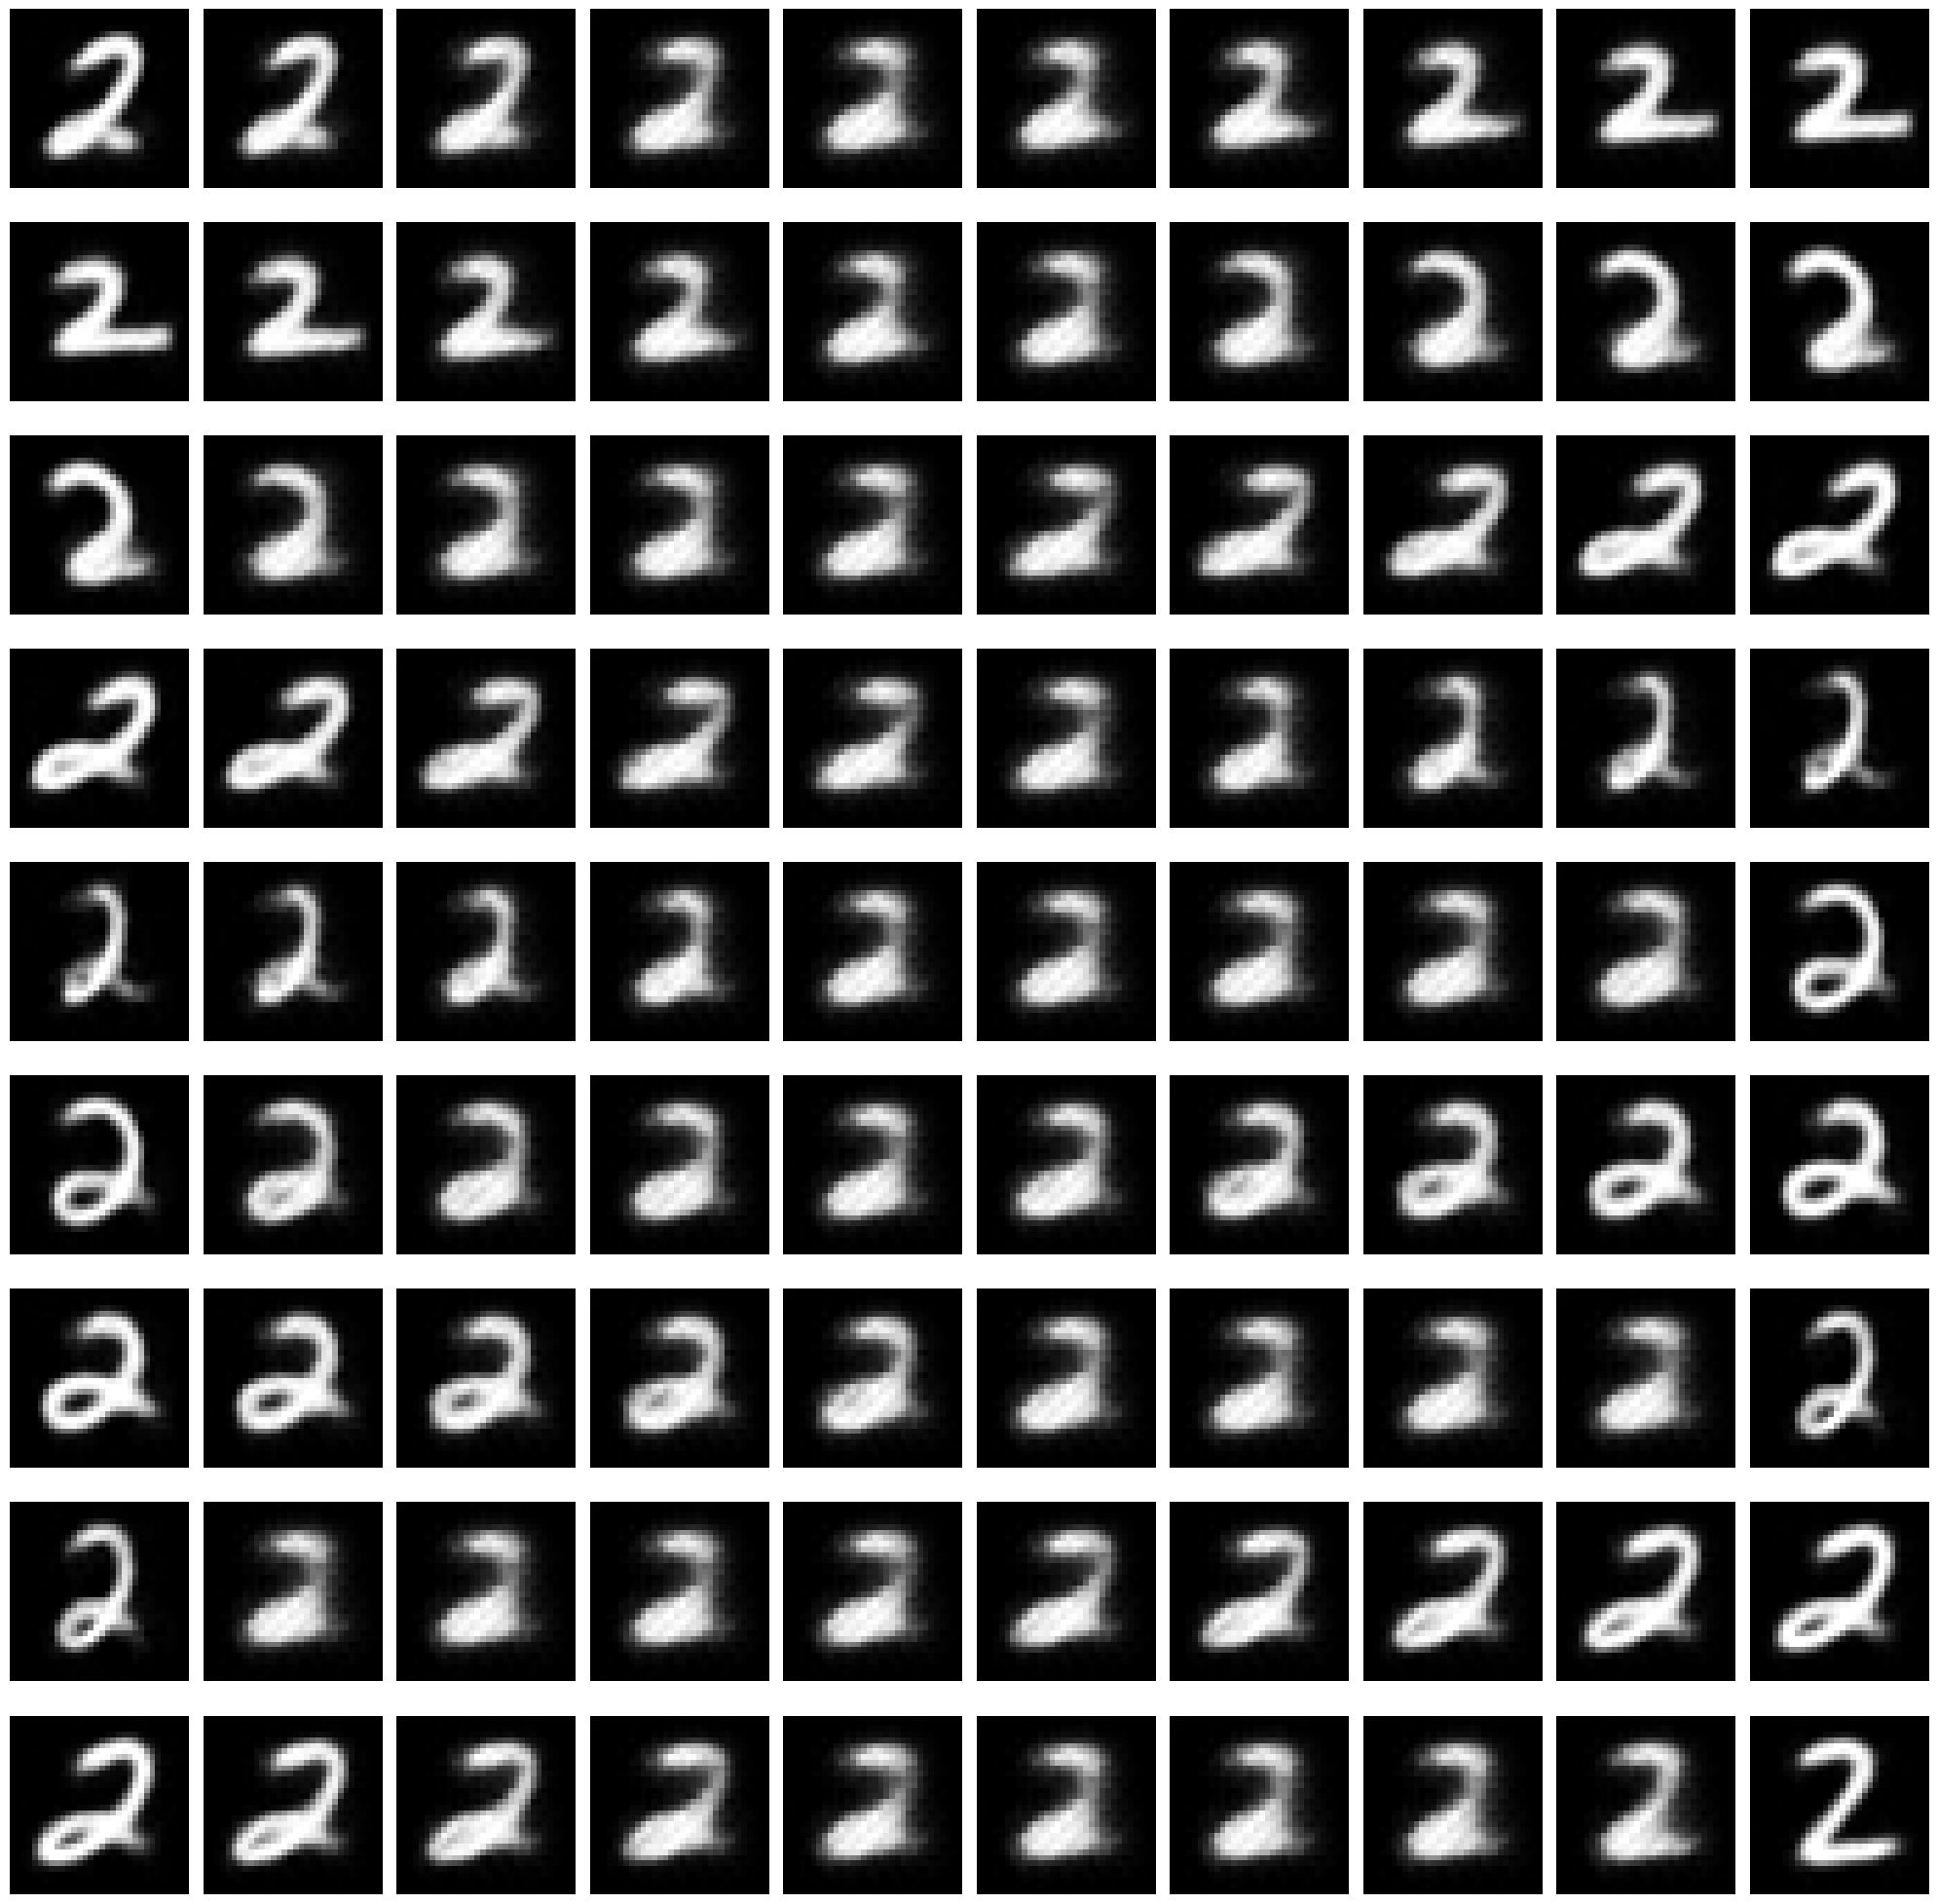

In [22]:
# compute iso geodesics between all pairs of points
with torch.no_grad():
    iso_Omega_geodesics = iso_Omega_manifold.geodesic(archetypes_train[None].to(device), archetypes_train[None].to(device), t.to(device))[0].cpu()

# plot iso-geodesics
fig, axes = plt.subplots(n_classes-1, steps, figsize=(int(steps / n_classes * 20), 20))
axes = axes.flatten()
for i in range(n_classes-1):
    for k in range(steps):
        axes[i*steps + k].imshow(iso_Omega_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_iso.png"))
plt.show()

In [23]:
# construct RAM
# ram = RiemannianArchetypalMapping(phi_manifold, archetypes_train)
ram = RiemannianArchetypalMapping(Omega_manifold, archetypes_train)

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/src/nn/module/riemannian/archetypal_mapping.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("pgd_step_tensor", torch.tensor(step, dtype=A.dtype, device=A.device))


In [24]:
# project clusters
n_projections = 10
with torch.no_grad():
    ram_projected_data_val = ram.forward(data_val[:n_projections].to(device))
    ram_projected_archetypes_train = ram.forward(archetypes_train.to(device))

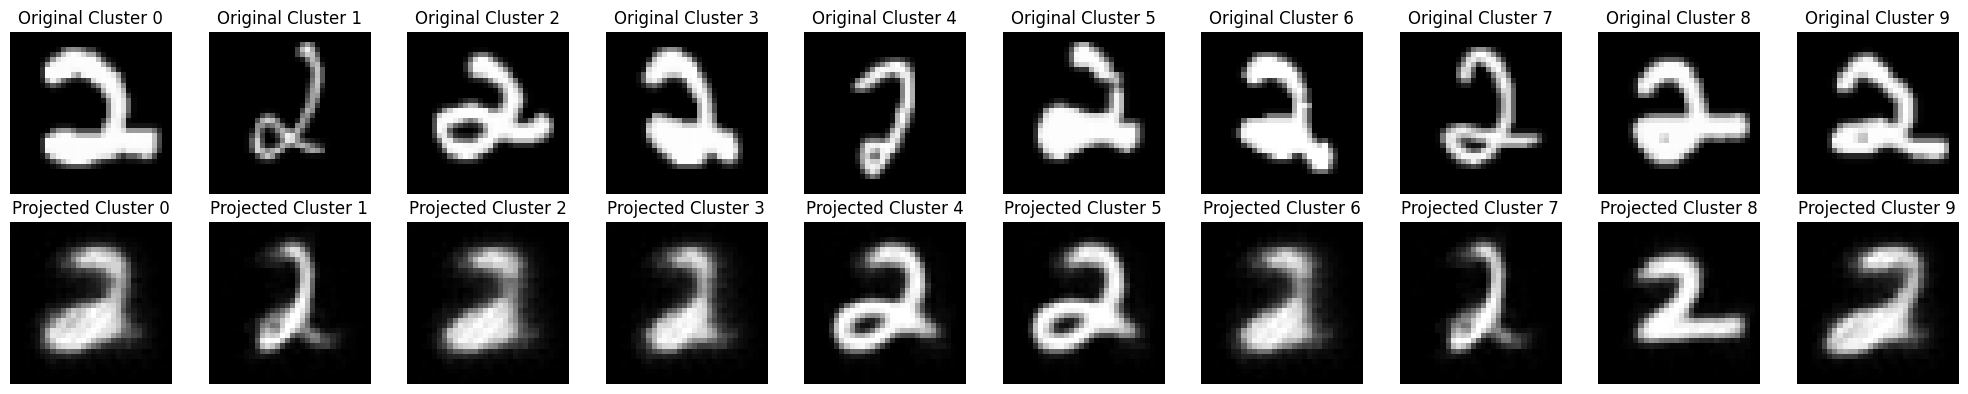

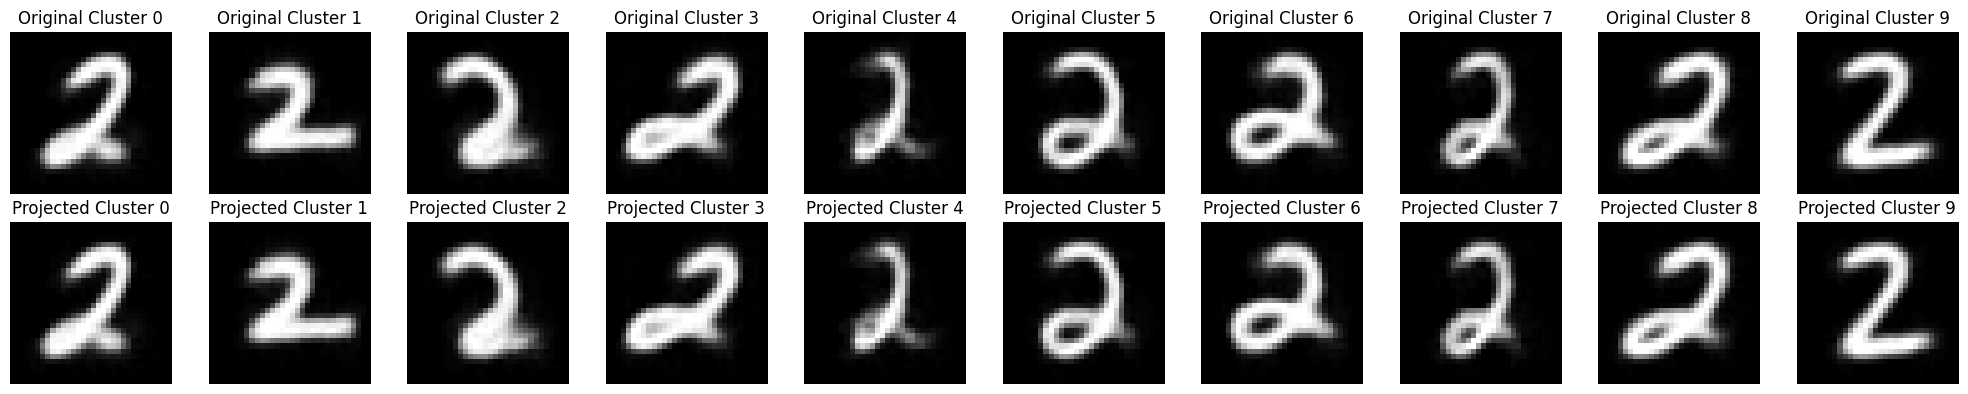

In [25]:
# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, n_projections, figsize=(2 * n_projections, 4))
for i in range(n_projections):
    axes[0, i].imshow(data_val[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_projected_data_val[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, n_classes, figsize=(2 * n_classes, 4))
for i in range(n_classes):
    axes[0, i].imshow(archetypes_train[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_projected_archetypes_train[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()